# **Cross Validation Techniques**

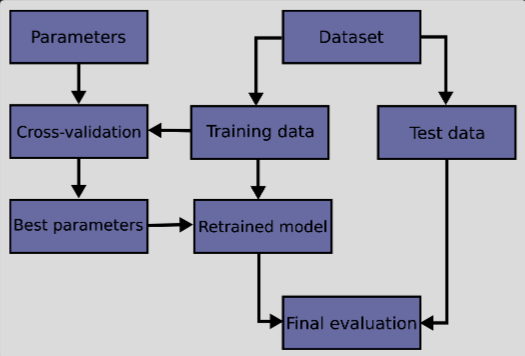

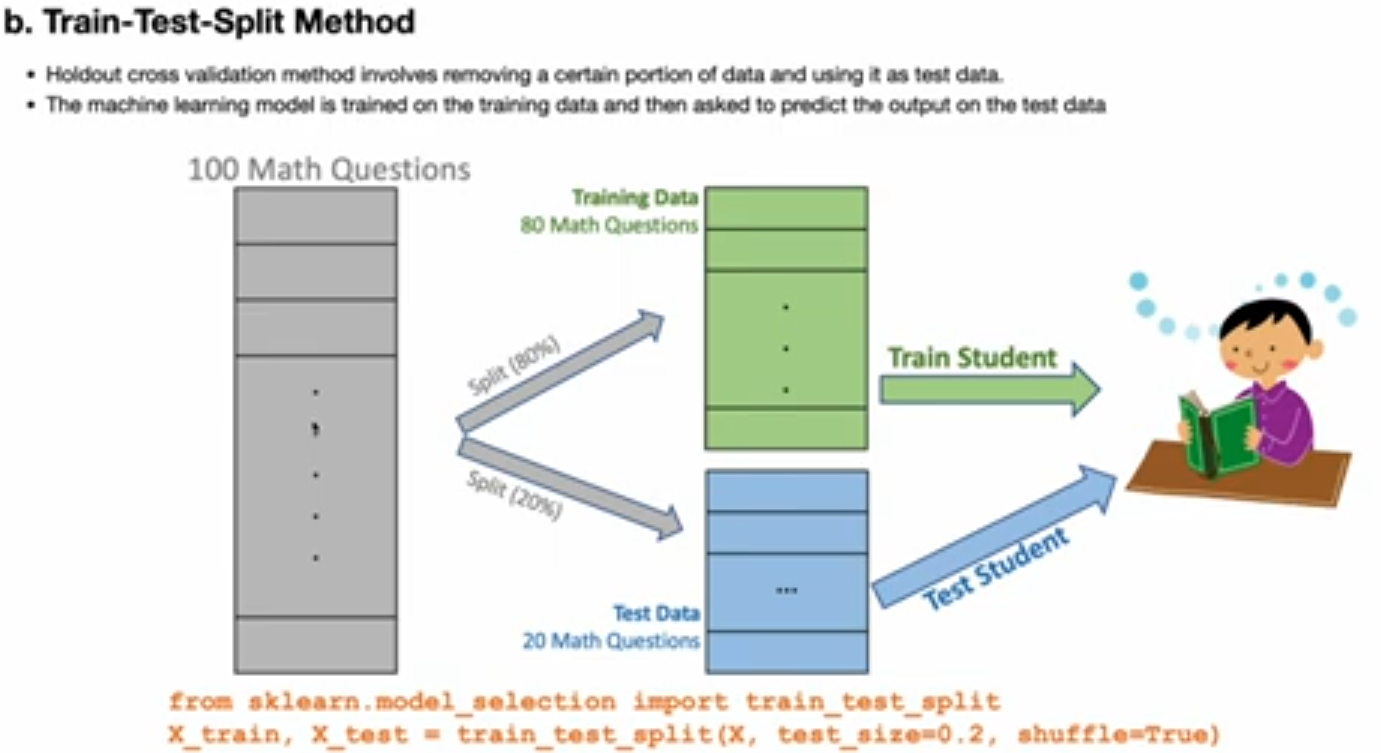

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

x = np.arange(1,101)
x_train, x_test = train_test_split(x, test_size=0.2, shuffle=True)
print("Avaiable Data: ", x)
print("Training Data: ", x_train)
print("Testing Data: ", x_test)

Avaiable Data:  [  1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18
  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36
  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53  54
  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71  72
  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89  90
  91  92  93  94  95  96  97  98  99 100]
Training Data:  [ 36  87  35  76  32  19  44 100  10  29  79  42  18  92   4  82  47  66
  81  27  11  60  64   2   7  12  25  94  80  61  57  65  17  58  95  23
  91  30  45  16  31  93  68  20  37  74  50  51  98  53  40  28  88  71
  75  96  22  48  84  67  70  86  83   5  26  99  33   3  38  77  97   6
  54   1  14  90  13  41  72  56]
Testing Data:  [49 46 59 62 73 15 85 89 43  8 34 52  9 63 55 21 78 69 39 24]


In [2]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import pandas as pd
from sklearn.model_selection import train_test_split


df = pd.read_csv(r"D:\Codes\MachineLearning\Datasets\advertising4D.csv")

x = df.drop("sales", axis=1)
y = df["sales"]

x_train, x_test , y_train, y_test = train_test_split(x, y, test_size=0.2, shuffle=True)

lr = LinearRegression()

lr.fit(x_train, y_train)

r2 = r2_score(y_test, lr.predict(x_test))
r2 = lr.score(x_test, y_test)

print("R2 Scores: ", r2)


R2 Scores:  0.9127064038100896


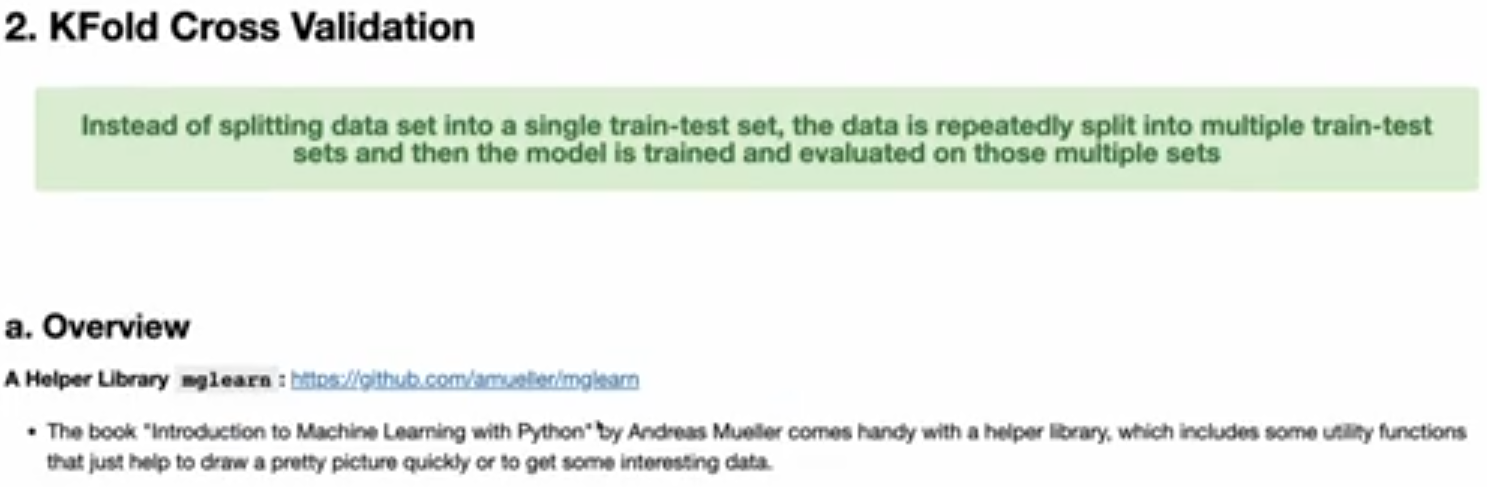

In [4]:
import sys
!{sys.executable} -m pip install mglearn graphviz -q

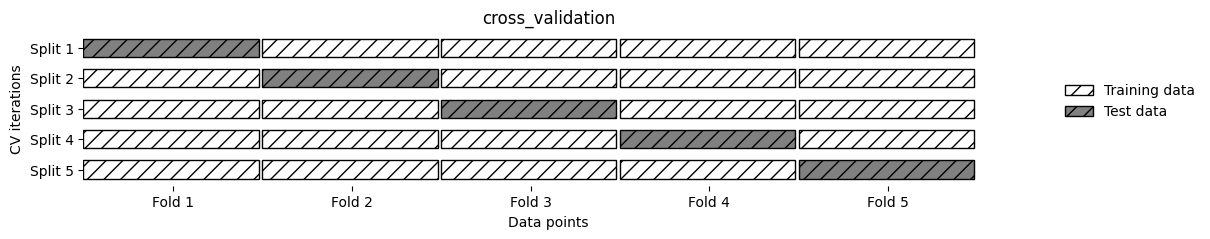

In [6]:
import mglearn
import matplotlib.pyplot as plt

# Try plotting something from mglearn
mglearn.plots.plot_cross_validation()
plt.show()


In [13]:
from sklearn.model_selection import KFold
x = [0,1,2,3,4,5,6,7,8,9]
kf = KFold(n_splits=10, shuffle=True)
for train_indices, test_indices in kf.split(x):
    print(train_indices, test_indices)

[0 1 2 3 4 5 6 7 9] [8]
[0 1 2 3 4 5 7 8 9] [6]
[0 1 2 3 4 5 6 8 9] [7]
[0 1 2 4 5 6 7 8 9] [3]
[0 1 3 4 5 6 7 8 9] [2]
[0 2 3 4 5 6 7 8 9] [1]
[0 1 2 3 5 6 7 8 9] [4]
[1 2 3 4 5 6 7 8 9] [0]
[0 1 2 3 4 6 7 8 9] [5]
[0 1 2 3 4 5 6 7 8] [9]


In [14]:
df = pd.read_csv(r"D:\Codes\MachineLearning\Datasets\advertising4D.csv")

x = df.drop("sales", axis=1)
y = df["sales"]

kf = KFold(n_splits=5, shuffle=True)
i = 1

for train_indices, test_indices in kf.split(x,y):
    print("\nSplites: {}".format(i))
    print("Test Indices: ", test_indices)
    print("Training Indices: " ,test_indices)

    i = i + 1




Splites: 1
Test Indices:  [ 17  21  22  26  30  33  41  42  47  49  54  56  59  63  73  80  84  88
 107 117 129 130 132 138 139 141 143 145 146 152 153 154 159 162 176 183
 184 192 198 199]
Training Indices:  [ 17  21  22  26  30  33  41  42  47  49  54  56  59  63  73  80  84  88
 107 117 129 130 132 138 139 141 143 145 146 152 153 154 159 162 176 183
 184 192 198 199]

Splites: 2
Test Indices:  [  3   8  15  19  27  31  38  43  46  48  57  61  62  68  74  78  87  92
  93  95 108 109 114 118 124 126 127 136 144 150 158 160 164 165 170 173
 182 186 193 197]
Training Indices:  [  3   8  15  19  27  31  38  43  46  48  57  61  62  68  74  78  87  92
  93  95 108 109 114 118 124 126 127 136 144 150 158 160 164 165 170 173
 182 186 193 197]

Splites: 3
Test Indices:  [  0   7  14  24  37  50  52  55  58  69  72  75  77  79  85  90  91  97
  98 100 111 115 119 120 121 123 131 133 140 157 171 175 178 180 181 185
 187 188 191 196]
Training Indices:  [  0   7  14  24  37  50  52  55  58  69  

In [15]:
def get_score(model, x_train, x_test , y_train, y_test):
    model.fit(x_train, y_train)
    return model.score(x_test, y_test)

In [16]:
from sklearn.linear_model import LinearRegression
df = pd.read_csv(r"D:\Codes\MachineLearning\Datasets\advertising4D.csv")

x = df.drop("sales", axis=1)
y = df["sales"]

kf = KFold(n_splits=5, shuffle=False)

score_list = []

for train_indices, test_indices in kf.split(x,y):
    x_train, x_test, y_train, y_test = x.iloc[train_indices], x.iloc[test_indices], y[train_indices], y[test_indices]
    score_list.append(get_score(LinearRegression(),x_train, x_test , y_train, y_test )) 
    
score_list

print("R2 Score: ", score_list)
print("Mean R2 Score: ", np.mean(score_list))


R2 Score:  [0.8786519804831341, 0.9176321165614462, 0.9293303235799653, 0.8144390391722338, 0.8954782879224387]
Mean R2 Score:  0.8871063495438436


## **Using Cross Validation Method:**

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
df = pd.read_csv(r"D:\Codes\MachineLearning\Datasets\advertising4D.csv")

x = df.drop("sales", axis=1)
y = df["sales"]

kf = KFold(n_splits=5, shuffle=False)

score_arr = cross_val_score(LinearRegression(), x, y, cv=kf)

print("R2 Score: ", score_arr)
print("Mean R2 Score: ", np.mean(score_arr))


R2 Score:  [0.87865198 0.91763212 0.92933032 0.81443904 0.89547829]
Mean R2 Score:  0.8871063495438436


In [19]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_validate
df = pd.read_csv(r"D:\Codes\MachineLearning\Datasets\advertising4D.csv")

x = df.drop("sales", axis=1)
y = df["sales"]

kf = KFold(n_splits=5, shuffle=False)

Result = cross_validate(LinearRegression(), x, y, cv=kf)

Result


{'fit_time': array([0.0100584 , 0.00945139, 0.00840735, 0.01049042, 0.00995445]),
 'score_time': array([0.00682688, 0.0060699 , 0.0069766 , 0.00678945, 0.00663233]),
 'test_score': array([0.87865198, 0.91763212, 0.92933032, 0.81443904, 0.89547829])}

In [21]:
Result = cross_validate(LinearRegression(), x, y, cv=kf, return_train_score=True, return_estimator=True)

df = pd.DataFrame(Result)
df

,fit_time,score_time,estimator,test_score,train_score
0,0.013787,0.006205,LinearRegression(),0.878652,0.901013
1,0.008203,0.006042,LinearRegression(),0.917632,0.890396
2,0.011306,0.008091,LinearRegression(),0.929330,0.889693
3,0.011854,0.009368,LinearRegression(),0.814439,0.914588
4,0.010416,0.008183,LinearRegression(),0.895478,0.896152


# **New Section # 18**
**Cross Validation Techniques**

In [ ]:
!pip install mglearn

In [ ]:
import mglearn
from sklearn.model_selection import KFold


i = 1
kf = KFold(n_splits=5, shuffle=True)
for train_indices, test_indices in kf.split(X,y):
    print(f"\nSplites: {i}")
    print("Test Indices: ", test_indices)
    print("Training Indices: " ,test_indices)

    i = i + 1


def get_score(model, x_train, x_test , y_train, y_test):
    model.fit(x_train, y_train)
    return model.score(x_test, y_test)

In [ ]:

from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LinearRegression
import numpy as np

kf = KFold(n_splits=5, shuffle=True, random_state=42)

model = LinearRegression()

score_list = cross_val_score(model, X, y, cv=kf, scoring='r2')

# Print scores
print("R2 Scores for each fold:", score_list)
print("Mean R2 Score:", np.mean(score_list))

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
from sklearn.model_selection import cross_validate

df = pd.read_csv('advertising4D.csv')
df

In [ ]:
X = df.drop('sales', axis=1)
y = df['sales']

In [ ]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
result = cross_validate(LinearRegression(), X, y, cv=kf, return_estimator=True)
print(result)

In [ ]:
df = pd.DataFrame(result)
print(df['test_score'].mean())
df

**StritifiedKfold Cross Validation**
StritifiedKfold uses for classification

In [2]:
!pip install mglearn

   ---------------------------------------- 0.0/581.4 kB ? eta -:--:--
   ---------------------------------------- 0.0/581.4 kB ? eta -:--:--
   ------------------ --------------------- 262.1/581.4 kB ? eta -:--:--
   ---------------------------------------- 581.4/581.4 kB 1.8 MB/s  0:00:00

   ---------------------------------------- 0/2 [imageio]
   ---------------------------------------- 0/2 [imageio]
   ---------------------------------------- 0/2 [imageio]
   ---------------------------------------- 0/2 [imageio]
   ---------------------------------------- 0/2 [imageio]
   ---------------------------------------- 0/2 [imageio]
   -------------------- ------------------- 1/2 [mglearn]
   -------------------- ------------------- 1/2 [mglearn]
   ---------------------------------------- 2/2 [mglearn]



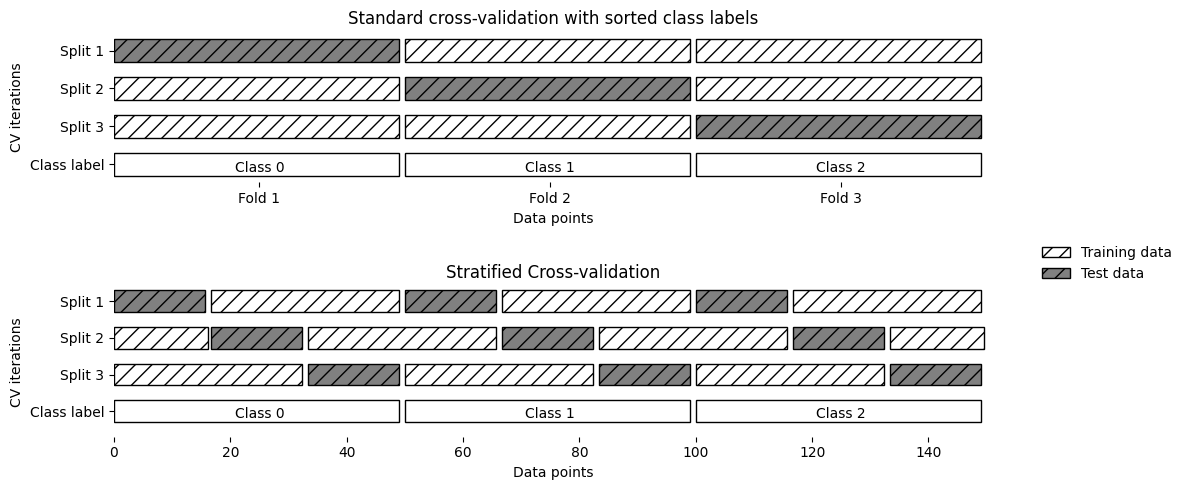

In [3]:
import mglearn

mglearn.plots.plot_stratified_cross_validation()

In [4]:
from sklearn.datasets import load_iris
import pandas as pd

iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['target'] = iris.target

X = df.drop('target', axis=1)
y = df['target']

In [5]:
from sklearn.model_selection import cross_validate, KFold
from sklearn.linear_model import LogisticRegression

kf = KFold(n_splits=3, shuffle=False)
log_reg = LogisticRegression()

result = cross_validate(log_reg, X, y, cv=kf, scoring='accuracy', return_estimator=True)
print("Logistic Regression Results:", result)

Logistic Regression Results: {'fit_time': array([0.01813769, 0.01209831, 0.01167178]), 'score_time': array([0.00182605, 0.00170803, 0.00173187]), 'estimator': [LogisticRegression(), LogisticRegression(), LogisticRegression()], 'test_score': array([0., 0., 0.])}


In [6]:
result = pd.DataFrame(result)
result

,fit_time,score_time,estimator,test_score
0,0.018138,0.001826,LogisticRegression(),0.0
1,0.012098,0.001708,LogisticRegression(),0.0
2,0.011672,0.001732,LogisticRegression(),0.0


**Time Series Split**

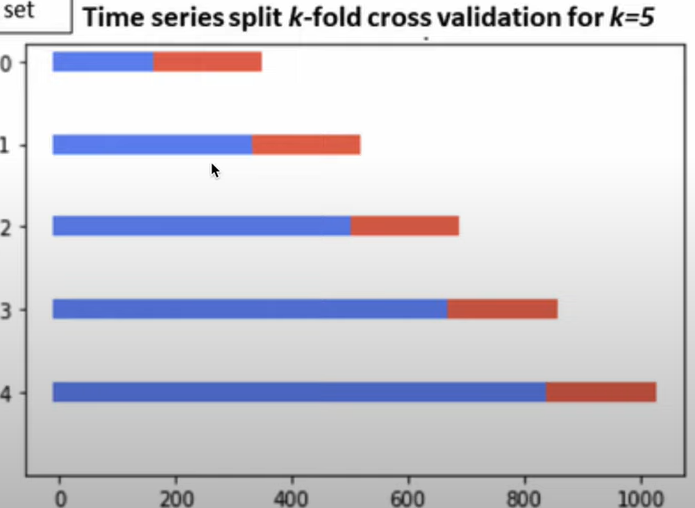


In [7]:
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression


log_reg = LogisticRegression()
skf = StratifiedKFold(n_splits=3, shuffle=True)
result = cross_validate(log_reg, X, y, cv=skf, scoring='accuracy', return_estimator=True)
print("Logistic Regression Results:", result)

result = pd.DataFrame(result)
result

Logistic Regression Results: {'fit_time': array([0.0563848 , 0.03880262, 0.03249741]), 'score_time': array([0.00190735, 0.0018158 , 0.00154495]), 'estimator': [LogisticRegression(), LogisticRegression(), LogisticRegression()], 'test_score': array([0.98, 0.96, 0.98])}


,fit_time,score_time,estimator,test_score
0,0.056385,0.001907,LogisticRegression(),0.98
1,0.038803,0.001816,LogisticRegression(),0.96
2,0.032497,0.001545,LogisticRegression(),0.98
